In [31]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Early stopping class

In [32]:
class EarlyStopping:
    def __init__(self, patience=15, delta=0.0001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# Weighted MSE loss

In [33]:
class WeightedMSELoss(nn.Module):
    """
    MSE Loss that gives more weight to higher target values.
    This helps the model learn to predict rare high CISI values better.
    """
    def __init__(self, weight_factor=10.0):
        super().__init__()
        self.weight_factor = weight_factor
    
    def forward(self, pred, target):
        # Higher CISI values get more weight
        # Weight = 1 + weight_factor * target
        weights = 1.0 + self.weight_factor * target
        
        squared_error = (pred - target) ** 2
        weighted_loss = weights * squared_error
        
        return weighted_loss.mean()

# CNN Model

In [34]:
class CNN(nn.Module):
    def __init__(self, config):
        super(CNN, self).__init__()

        self.config = config

        # 3 Layers of the CNN
        self.conv_layers = nn.Sequential(
            nn.Conv2d(9, 16, kernel_size=3, padding=1), # 9 channels
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),
        )

        # Makes model patch-size independent
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully connected regression head
        self.fc_layers = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc_layers(x)

        # Temperature scaling
        temperature = 2.5  # Higher = less squashing
        x = torch.sigmoid(x / temperature)
        # x = torch.sigmoid(x) # Sigmoid activation function
        # x = torch.clamp(x, 0, 1) # Linear clip to valid range
        return x


# Dataset Class

In [35]:
class CISIDataset(Dataset):
    def __init__(self, gdp_path, pop_path, lc_path, cisi_path, 
                 oversample_high_cisi=False, high_cisi_threshold=0.1, oversample_factor=10):
        
        # Load all data
        with rasterio.open(gdp_path) as src:
            self.gdp = src.read(1).astype(np.float32)
        
        with rasterio.open(pop_path) as src:
            self.pop = src.read(1).astype(np.float32)
        
        with rasterio.open(lc_path) as src:
            self.lc = src.read().astype(np.float32)
        
        with rasterio.open(cisi_path) as src:
            self.cisi = src.read(1).astype(np.float32)
        
        # ========================================
        # CREATE VALID MASK FIRST
        # ========================================
        valid_gdp = ~np.isnan(self.gdp)
        valid_pop = ~np.isnan(self.pop)
        valid_cisi = ~np.isnan(self.cisi)
        
        self.valid_mask = valid_gdp & valid_pop & valid_cisi
        
        # ========================================
        # THEN GET VALID INDICES
        # ========================================
        self.valid_indices = np.argwhere(self.valid_mask)
        base_count = len(self.valid_indices)
        
        print(f"Found {base_count:,} valid pixels")
        
        # ========================================
        # OVERSAMPLING (if enabled)
        # ========================================
        if oversample_high_cisi:
            # Find high CISI pixels
            high_cisi_mask = (self.cisi > high_cisi_threshold) & self.valid_mask
            high_cisi_indices = np.argwhere(high_cisi_mask)
            
            print(f"\n OVERSAMPLING STATISTICS:")
            print(f"  Base valid pixels: {base_count:,}")
            print(f"  High CISI pixels (>{high_cisi_threshold}): {len(high_cisi_indices):,} "
                  f"({len(high_cisi_indices)/base_count*100:.1f}%)")
            
            # Add high CISI pixels multiple times
            for _ in range(oversample_factor - 1):
                self.valid_indices = np.vstack([self.valid_indices, high_cisi_indices])
            
            print(f"  After oversampling: {len(self.valid_indices):,} total samples")
            print(f"  High CISI proportion: "
                  f"{len(high_cisi_indices) * oversample_factor / len(self.valid_indices) * 100:.1f}%")
        
        print(f"\n Final dataset: {len(self.valid_indices):,} samples")
    
    def __len__(self):
        return len(self.valid_indices)
    
    def __getitem__(self, idx):
        patch_size = 8
        half_patch = patch_size // 2
        max_tries = 50
        tries = 0

        while True:
            i, j = self.valid_indices[idx]

            # Handle boundaries
            i_start = max(0, i - half_patch)
            i_end = min(self.gdp.shape[0], i + half_patch)
            j_start = max(0, j - half_patch)
            j_end = min(self.gdp.shape[1], j + half_patch)

            # Extract patches
            gdp_patch = self.gdp[i_start:i_end, j_start:j_end].copy()
            pop_patch = self.pop[i_start:i_end, j_start:j_end].copy()
            lc_patch  = self.lc[:, i_start:i_end, j_start:j_end].copy()

            # Pad to patch_size if needed
            pad_i = patch_size - gdp_patch.shape[0]
            pad_j = patch_size - gdp_patch.shape[1]

            if pad_i > 0 or pad_j > 0:
                gdp_patch = np.pad(gdp_patch, ((0, pad_i), (0, pad_j)))
                pop_patch = np.pad(pop_patch, ((0, pad_i), (0, pad_j)))
                lc_patch  = np.pad(lc_patch, ((0, 0), (0, pad_i), (0, pad_j)))

            # Check if patch is valid
            if np.isfinite(gdp_patch).all() and np.isfinite(pop_patch).all():
                break

            # Try different index
            tries += 1
            if tries >= max_tries:
                gdp_patch = np.nan_to_num(gdp_patch, nan=0.0, posinf=0.0, neginf=0.0)
                pop_patch = np.nan_to_num(pop_patch, nan=0.0, posinf=0.0, neginf=0.0)
                break

            idx = np.random.randint(0, len(self.valid_indices))

        # Stack: (9, 32, 32)
        input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)
        target = self.cisi[i, j]

        input_tensor = torch.FloatTensor(input_tensor)
        target = torch.FloatTensor([target])

        return input_tensor, target, (i, j)

# Tiling Function

In [36]:
# tiling function here

# Training Function

In [37]:
def training(
    num_epochs,
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    clip_value,
    device,
    wandbrun=None,
    sigmoidcnn=False
):
    train_loss_list = []
    val_loss_list = []

    early_stopping = EarlyStopping()

    for epoch in range(num_epochs):
        # ========== TRAINING ==========
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            inputs, targets, _ = batch
            inputs = inputs.to(device)
            targets = targets.to(device).view(-1, 1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_loss_list.append(avg_train_loss)

        # ========== VALIDATION ==========
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                inputs, targets, _ = batch
                inputs = inputs.to(device)
                targets = targets.to(device).view(-1, 1)

                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_loss_list.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Early stopping check
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break

    return train_loss_list, val_loss_list

# Paths 0.10

In [38]:
# gdp_path = r"READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif"
# pop_path = r"READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif"
# lc_path = r"READY_data\landuse_onehot\clipped_history_2020_onehot.tif"
# cisi_path = r"READY_data\labels\2024_CISI_010deg_nearest.tif"

In [39]:
# with rasterio.open(r'READY_data\labels\2024_CISI_010deg_nearest.tif') as src:
#     data = src.read(1)
#     print(f"Shape: {data.shape}")
#     print(f"Max: {np.nanmax(data):.4f}")

# Paths 0.25

In [40]:
gdp_path = r"READY_data\inputs_normalized\2019_gdp_aligned_025_normalized.tif"
pop_path = r"READY_data\inputs_normalized\2020_pop_aligned_025_normalized.tif"
lc_path = r"READY_data\landuse_onehot_025\clipped_history_2020_025_onehot.tif"
cisi_path = r"READY_data\labels\CISI_025deg_corrected.tif"

In [41]:
with rasterio.open(r'READY_data\labels\CISI_025deg_corrected.tif') as src:
    data = src.read(1)
    print(f"Shape: {data.shape}")
    print(f"Max: {np.nanmax(data):.4f}")

Shape: (194, 228)
Max: 1.0000


# Dataset and Split

In [42]:
# Manual stratified split (no sklearn)
dataset = CISIDataset(gdp_path, pop_path, lc_path, cisi_path)
cisi_values = np.array([dataset.cisi[i, j] for i, j in dataset.valid_indices])

# Separate high and low CISI
high_threshold = 0.15
high_mask = cisi_values > high_threshold
low_mask = ~high_mask

high_indices = np.where(high_mask)[0]
low_indices = np.where(low_mask)[0]

# Shuffle and split each group
np.random.seed(42)
np.random.shuffle(high_indices)
np.random.shuffle(low_indices)

# 80/20 split for each group
high_split = int(0.8 * len(high_indices))
low_split = int(0.8 * len(low_indices))

train_idx = np.concatenate([high_indices[:high_split], low_indices[:low_split]])
val_idx = np.concatenate([high_indices[high_split:], low_indices[low_split:]])

# Create subsets
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)

print(f"Train: {len(train_dataset):,}, Val: {len(val_dataset):,}")
print(f"High CISI in train: {(cisi_values[train_idx] > high_threshold).sum()}")
print(f"High CISI in val: {(cisi_values[val_idx] > high_threshold).sum()}")

Found 11,944 valid pixels

 Final dataset: 11,944 samples
Train: 9,554, Val: 2,390
High CISI in train: 365
High CISI in val: 92


# Create Dataloaders

In [43]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, drop_last=True)

TRAIN SET:
  Mean: 0.0473, Std: 0.0545
  Range: [0.0000, 1.0000]

VAL SET:
  Mean: 0.0457, Std: 0.0502
  Range: [0.0000, 0.5617]


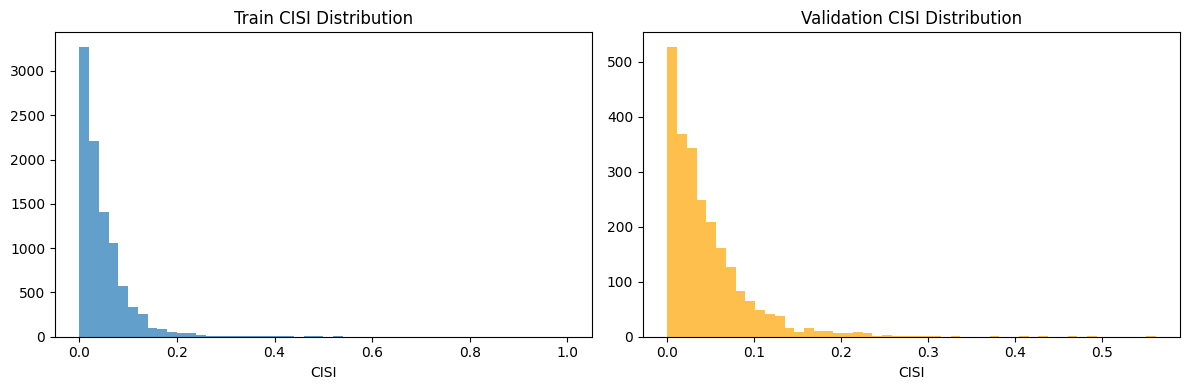

In [44]:
train_targets = []
val_targets = []

for _, target, _ in train_loader:
    train_targets.extend(target.numpy().flatten())

for _, target, _ in val_loader:
    val_targets.extend(target.numpy().flatten())

train_targets = np.array(train_targets)
val_targets = np.array(val_targets)

print("TRAIN SET:")
print(f"  Mean: {train_targets.mean():.4f}, Std: {train_targets.std():.4f}")
print(f"  Range: [{train_targets.min():.4f}, {train_targets.max():.4f}]")

print("\nVAL SET:")
print(f"  Mean: {val_targets.mean():.4f}, Std: {val_targets.std():.4f}")
print(f"  Range: [{val_targets.min():.4f}, {val_targets.max():.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_targets, bins=50, alpha=0.7, label='Train')
axes[0].set_title('Train CISI Distribution')
axes[0].set_xlabel('CISI')

axes[1].hist(val_targets, bins=50, alpha=0.7, label='Val', color='orange')
axes[1].set_title('Validation CISI Distribution')
axes[1].set_xlabel('CISI')

plt.tight_layout()
plt.show()

# Init Model

In [45]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

config = {'dropout': 0.3}
model = CNN(config).to(device)

# criterion = nn.HuberLoss(dessss
criterion = WeightedMSELoss(weight_factor=25.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using device: cpu


# Train Model

In [46]:
train_loss_list, val_loss_list = training(
    num_epochs=50,
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    clip_value=1.0,
    device=device
)

Epoch [1/50] - Train Loss: 0.1779, Val Loss: 0.0289
Epoch [2/50] - Train Loss: 0.0272, Val Loss: 0.0098
Epoch [3/50] - Train Loss: 0.0155, Val Loss: 0.0132
Epoch [4/50] - Train Loss: 0.0117, Val Loss: 0.0097
Epoch [5/50] - Train Loss: 0.0122, Val Loss: 0.0092
Epoch [6/50] - Train Loss: 0.0105, Val Loss: 0.0091
Epoch [7/50] - Train Loss: 0.0097, Val Loss: 0.0128
Epoch [8/50] - Train Loss: 0.0083, Val Loss: 0.0093
Epoch [9/50] - Train Loss: 0.0082, Val Loss: 0.0099
Epoch [10/50] - Train Loss: 0.0087, Val Loss: 0.0097
Epoch [11/50] - Train Loss: 0.0082, Val Loss: 0.0076
Epoch [12/50] - Train Loss: 0.0083, Val Loss: 0.0084
Epoch [13/50] - Train Loss: 0.0079, Val Loss: 0.0079
Epoch [14/50] - Train Loss: 0.0074, Val Loss: 0.0064
Epoch [15/50] - Train Loss: 0.0068, Val Loss: 0.0108
Epoch [16/50] - Train Loss: 0.0063, Val Loss: 0.0093
Epoch [17/50] - Train Loss: 0.0073, Val Loss: 0.0078
Epoch [18/50] - Train Loss: 0.0072, Val Loss: 0.0097
Epoch [19/50] - Train Loss: 0.0066, Val Loss: 0.0075
Ep

# Plotting some results

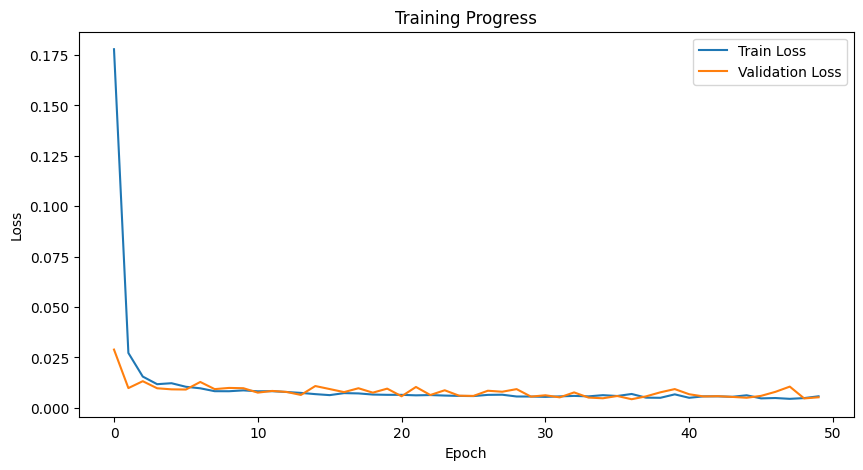

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Progress')
plt.show()

# Full Dataset Evaluation

# Generate predictions

In [48]:
model.eval()
predictions = []
actuals = []
coordinates = []

with torch.no_grad():
    for batch in val_loader:
        inputs, targets, coords = batch
        inputs = inputs.to(device)
        
        outputs = model(inputs)
        
        predictions.extend(outputs.cpu().numpy().flatten())
        actuals.extend(targets.numpy().flatten())
        coordinates.extend(coords)

predictions = np.array(predictions)
actuals = np.array(actuals)

print(f"Predictions range: [{predictions.min():.3f}, {predictions.max():.3f}]")
print(f"Actuals range: [{actuals.min():.3f}, {actuals.max():.3f}]")

Predictions range: [0.005, 0.453]
Actuals range: [0.000, 0.562]


# Visualize Results

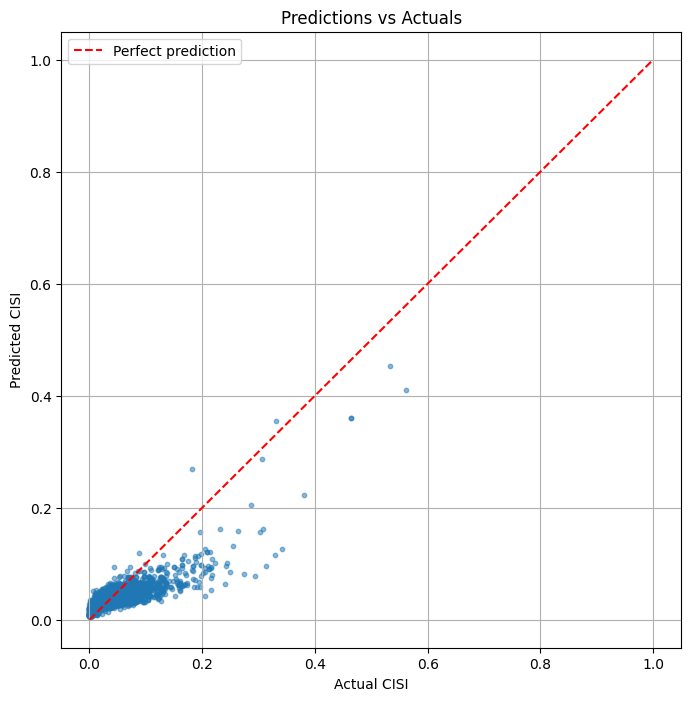

In [49]:
plt.figure(figsize=(8, 8))
plt.scatter(actuals, predictions, alpha=0.5, s=10)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
plt.xlabel('Actual CISI')
plt.ylabel('Predicted CISI')
plt.title('Predictions vs Actuals')
plt.legend()
plt.grid(True)
plt.show()

# Metrics

In [50]:
mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(actuals, predictions)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MSE: 0.0010
MAE: 0.0199
RMSE: 0.0314
R² Score: 0.5940


=== ACTUALS ===
Mean: 0.0449
Std: 0.0493
Range: [0.0000, 0.5617]

=== PREDICTIONS ===
Mean: 0.0381
Std: 0.0266
Range: [0.0048, 0.4529]


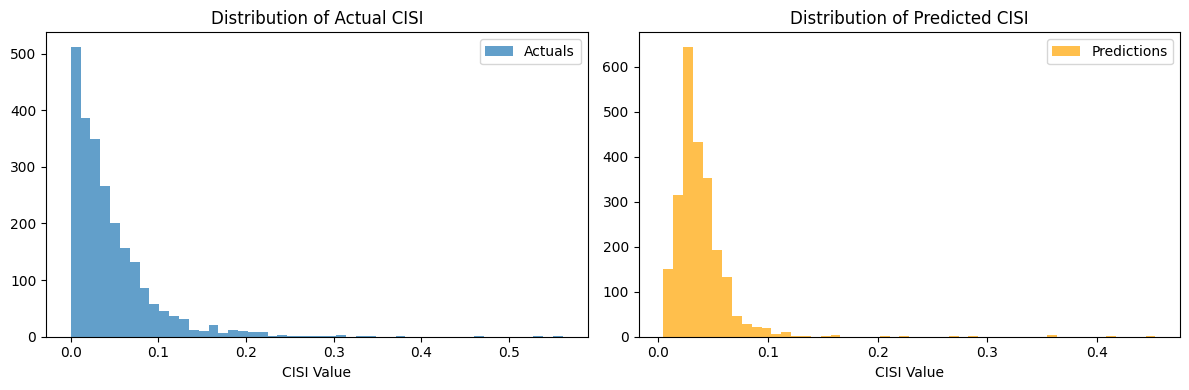

In [51]:
# Check distributions
print("=== ACTUALS ===")
print(f"Mean: {actuals.mean():.4f}")
print(f"Std: {actuals.std():.4f}")
print(f"Range: [{actuals.min():.4f}, {actuals.max():.4f}]")

print("\n=== PREDICTIONS ===")
print(f"Mean: {predictions.mean():.4f}")
print(f"Std: {predictions.std():.4f}")
print(f"Range: [{predictions.min():.4f}, {predictions.max():.4f}]")

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(actuals, bins=50, alpha=0.7, label='Actuals')
axes[0].set_title('Distribution of Actual CISI')
axes[0].set_xlabel('CISI Value')
axes[0].legend()

axes[1].hist(predictions, bins=50, alpha=0.7, label='Predictions', color='orange')
axes[1].set_title('Distribution of Predicted CISI')
axes[1].set_xlabel('CISI Value')
axes[1].legend()

plt.tight_layout()
plt.show()

In [52]:
# Look at one sample from dataset
sample_input, sample_target, _ = dataset[0]

print("Input shape:", sample_input.shape)
print("\nInput statistics per channel:")
for i in range(9):
    channel = sample_input[i]
    print(f"Channel {i}: min={channel.min():.2f}, max={channel.max():.2f}, mean={channel.mean():.2f}")

print(f"\nTarget CISI value: {sample_target.item():.4f}")

Input shape: torch.Size([9, 8, 8])

Input statistics per channel:
Channel 0: min=-0.81, max=2.06, mean=0.02
Channel 1: min=-0.28, max=1.33, mean=0.36
Channel 2: min=0.00, max=0.00, mean=0.00
Channel 3: min=0.00, max=1.00, mean=0.52
Channel 4: min=0.00, max=1.00, mean=0.41
Channel 5: min=0.00, max=1.00, mean=0.08
Channel 6: min=0.00, max=0.00, mean=0.00
Channel 7: min=0.00, max=0.00, mean=0.00
Channel 8: min=0.00, max=0.00, mean=0.00

Target CISI value: 0.0197


# Save model

In [53]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save with descriptive name
model_path = 'models/cisi_model_exp26.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': train_loss_list,
    'val_loss': val_loss_list,
    'config': config,
    }
, model_path)

print(f"   Experiment  model saved to: {model_path}")
print(f"   Full path: {os.path.abspath(model_path)}")

   Experiment  model saved to: models/cisi_model_exp26.pth
   Full path: c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis\models\cisi_model_exp26.pth


# Debugging checks

In [54]:
# import torch
# import numpy as np

# print("=" * 70)
# print("CHECKING FIRST BATCH FROM DATALOADER")
# print("=" * 70)

# # Get one batch
# for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
#     print(f"\nBatch {batch_idx}:")
#     print(f"  Batch size: {inputs.shape[0]}")
#     print(f"  Input shape: {inputs.shape}")  # Should be (batch, 9, 32, 32)
#     print(f"  Target shape: {targets.shape}")  # Should be (batch, 1)
    
#     # Check for NaN/Inf in inputs
#     print(f"\n  INPUT CHECKS:")
#     print(f"    Contains NaN: {torch.isnan(inputs).any().item()}")
#     print(f"    Contains Inf: {torch.isinf(inputs).any().item()}")
#     print(f"    Min: {inputs.min().item():.4f}")
#     print(f"    Max: {inputs.max().item():.4f}")
#     print(f"    Mean: {inputs.mean().item():.4f}")
    
#     # Check for NaN/Inf in targets
#     print(f"\n  TARGET CHECKS:")
#     print(f"    Contains NaN: {torch.isnan(targets).any().item()}")
#     print(f"    Contains Inf: {torch.isinf(targets).any().item()}")
#     print(f"    Min: {targets.min().item():.4f}")
#     print(f"    Max: {targets.max().item():.4f}")
#     print(f"    Mean: {targets.mean().item():.4f}")
    
#     # Check each channel individually
#     print(f"\n  PER-CHANNEL CHECKS:")
#     channel_names = ['GDP', 'Pop', 'LC_0', 'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5', 'LC_6']
#     for ch in range(9):
#         ch_data = inputs[:, ch, :, :]
#         has_nan = torch.isnan(ch_data).any().item()
#         has_inf = torch.isinf(ch_data).any().item()
#         print(f"    {channel_names[ch]:6s}: min={ch_data.min().item():7.2f}, "
#               f"max={ch_data.max().item():7.2f}, "
#               f"NaN={has_nan}, Inf={has_inf}")
    
#     # Only check first batch
#     break

# print("\n" + "=" * 70)

In [55]:
# print("=" * 70)
# print("TESTING FORWARD PASS")
# print("=" * 70)

# model.eval()  # Set to eval mode first
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# with torch.no_grad():
#     for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
#         inputs = inputs.to(device)
#         targets = targets.to(device).view(-1, 1)
        
#         print(f"\nBatch {batch_idx}:")
#         print(f"  Input device: {inputs.device}")
#         print(f"  Input requires_grad: {inputs.requires_grad}")
        
#         # Forward pass
#         try:
#             outputs = model(inputs)
            
#             print(f"\n  OUTPUT CHECKS:")
#             print(f"    Output shape: {outputs.shape}")
#             print(f"    Contains NaN: {torch.isnan(outputs).any().item()}")
#             print(f"    Contains Inf: {torch.isinf(outputs).any().item()}")
#             print(f"    Min: {outputs.min().item():.4f}")
#             print(f"    Max: {outputs.max().item():.4f}")
#             print(f"    Mean: {outputs.mean().item():.4f}")
            
#             # Compute loss
#             loss = criterion(outputs, targets)
#             print(f"\n  LOSS:")
#             print(f"    Loss value: {loss.item():.4f}")
#             print(f"    Loss is NaN: {torch.isnan(loss).item()}")
#             print(f"    Loss is Inf: {torch.isinf(loss).item()}")
            
#         except Exception as e:
#             print(f"   ERROR during forward pass: {e}")
#             import traceback
#             traceback.print_exc()
        
#         # Only test first batch
#         break

# print("\n" + "=" * 70)

In [56]:
# print("=" * 70)
# print("DEBUGGING ONE TRAINING STEP")
# print("=" * 70)

# model.train()

# for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
#     inputs = inputs.to(device)
#     targets = targets.to(device).view(-1, 1)
    
#     print(f"\n=== STEP {batch_idx} ===")
    
#     # Zero gradients
#     optimizer.zero_grad()
    
#     # Forward
#     print("1. Forward pass...")
#     outputs = model(inputs)
#     print(f"   Outputs: min={outputs.min().item():.4f}, max={outputs.max().item():.4f}, "
#           f"NaN={torch.isnan(outputs).any().item()}")
    
#     # Loss
#     print("2. Computing loss...")
#     loss = criterion(outputs, targets)
#     print(f"   Loss: {loss.item():.4f}, NaN={torch.isnan(loss).item()}")
    
#     if torch.isnan(loss):
#         print("    NaN DETECTED IN LOSS!")
#         print(f"   Sample outputs: {outputs[:5].squeeze()}")
#         print(f"   Sample targets: {targets[:5].squeeze()}")
#         break
    
#     # Backward
#     print("3. Backward pass...")
#     loss.backward()
    
#     # Check gradients
#     print("4. Checking gradients...")
#     total_norm = 0
#     max_grad = 0
#     nan_grads = False
    
#     for name, param in model.named_parameters():
#         if param.grad is not None:
#             grad_norm = param.grad.data.norm(2).item()
#             total_norm += grad_norm ** 2
#             max_grad = max(max_grad, param.grad.abs().max().item())
            
#             if torch.isnan(param.grad).any():
#                 print(f"    NaN gradient in {name}")
#                 nan_grads = True
    
#     total_norm = total_norm ** 0.5
#     print(f"   Total gradient norm: {total_norm:.4f}")
#     print(f"   Max gradient value: {max_grad:.4f}")
    
#     if nan_grads:
#         print("    NaN DETECTED IN GRADIENTS!")
#         break
    
#     if total_norm > 1000:
#         print(f"    WARNING: Very large gradients! (norm={total_norm:.2f})")
    
#     # Clip
#     print("5. Clipping gradients...")
#     torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
#     # Step
#     print("6. Optimizer step...")
#     optimizer.step()
    
#     print("    Step complete\n")
    
#     # Only do 3 steps
#     if batch_idx >= 2:
#         break

# print("\n" + "=" * 70)

In [57]:
print("=" * 70)
print("CHECKING MODEL WEIGHTS")
print("=" * 70)

print("\nModel parameters:")
for name, param in model.named_parameters():
    print(f"  {name:40s}: shape={str(list(param.shape)):20s} "
          f"mean={param.data.mean().item():8.4f} "
          f"std={param.data.std().item():8.4f} "
          f"NaN={torch.isnan(param.data).any().item()}")

print("\n" + "=" * 70)

CHECKING MODEL WEIGHTS

Model parameters:
  conv_layers.0.weight                    : shape=[16, 9, 3, 3]        mean= -0.0071 std=  0.1411 NaN=False
  conv_layers.0.bias                      : shape=[16]                 mean=  0.0080 std=  0.0653 NaN=False
  conv_layers.1.weight                    : shape=[16]                 mean=  0.9935 std=  0.0521 NaN=False
  conv_layers.1.bias                      : shape=[16]                 mean= -0.2141 std=  0.1904 NaN=False
  conv_layers.5.weight                    : shape=[32, 16, 3, 3]       mean=  0.0027 std=  0.1158 NaN=False
  conv_layers.5.bias                      : shape=[32]                 mean=  0.0145 std=  0.0474 NaN=False
  conv_layers.6.weight                    : shape=[32]                 mean=  0.9918 std=  0.0939 NaN=False
  conv_layers.6.bias                      : shape=[32]                 mean= -0.2166 std=  0.1450 NaN=False
  conv_layers.10.weight                   : shape=[64, 32, 3, 3]       mean= -0.0028 std=  0.1

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_11736\2250598502.py:9: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  f"std={param.data.std().item():8.4f} "


In [58]:
import os
from pathlib import Path

# Check current working directory
print(f"Current directory: {os.getcwd()}")

# List files in current directory
print("\nFiles in current directory:")
for file in Path('.').glob('*.pth'):
    print(f"  ✅ {file}")

# Also check common locations
locations_to_check = [
    '.',
    './models',
    '../',
    str(Path.home() / 'Downloads'),
]

print("\nSearching for .pth files...")
for loc in locations_to_check:
    if os.path.exists(loc):
        pth_files = list(Path(loc).glob('**/*.pth'))
        if pth_files:
            print(f"\n📁 Found in {loc}:")
            for f in pth_files:
                print(f"  ✅ {f}")

Current directory: c:\Users\Gebruiker\Desktop\Thesis\FutureCISI-main\empy_repo_for_thesis

Files in current directory:
  ✅ cisi_model_2024.pth

Searching for .pth files...

📁 Found in .:
  ✅ cisi_model_2024.pth
  ✅ models\cisi_model_exp10.pth
  ✅ models\cisi_model_exp11.pth
  ✅ models\cisi_model_exp12_bilinear.pth
  ✅ models\cisi_model_exp13.pth
  ✅ models\cisi_model_exp14_nearest.pth
  ✅ models\cisi_model_exp15_clamp.pth
  ✅ models\cisi_model_exp16.pth
  ✅ models\cisi_model_exp17_weight100_1_5t.pth
  ✅ models\cisi_model_exp18_kfold.pth
  ✅ models\cisi_model_exp19_strat.pth
  ✅ models\cisi_model_exp20.pth
  ✅ models\cisi_model_exp21.pth
  ✅ models\cisi_model_exp22_16patch_010deg.pth
  ✅ models\cisi_model_exp23.pth
  ✅ models\cisi_model_exp24_15temp.pth
  ✅ models\cisi_model_exp25_notemp.pth
  ✅ models\cisi_model_exp26.pth
  ✅ models\cisi_model_exp2_oversample10x.pth
  ✅ models\cisi_model_exp3.pth
  ✅ models\cisi_model_exp4.pth
  ✅ models\cisi_model_exp5.pth
  ✅ models\cisi_model_exp6.p

In [59]:
print(f"Pred min: {predictions.min():.4f}")
print(f"Pred max: {predictions.max():.4f}")
print(f"Actual min: {actuals.min():.4f}")
print(f"Actual max: {actuals.max():.4f}")

Pred min: 0.0048
Pred max: 0.4529
Actual min: 0.0000
Actual max: 0.5617


In [60]:
import rasterio
import numpy as np

with rasterio.open(cisi_path) as src:
    cisi_data = src.read(1)
    print(f"CISI file max: {np.nanmax(cisi_data):.4f}")
    print(f"CISI file 99th percentile: {np.percentile(cisi_data[~np.isnan(cisi_data)], 99):.4f}")

CISI file max: 1.0000
CISI file 99th percentile: 0.2287
